In [2]:
from google.colab import files
uploaded = files.upload()

Saving df_train[1].csv to df_train[1].csv


In [3]:
import pandas as pd
df = pd.read_csv('/content/df_train[1].csv')

In [8]:
df.head()

,date,price,bedrooms,grade,has_basement,living_in_m2,renovated,nice_view,perfect_condition,real_bathrooms,has_lavatory,single_floor,month,quartile_zone
0,2014-05-15,312000.0,2,2,1,138.42547,0,0,0,2,1,0,5,1
1,2014-11-14,310000.0,2,2,0,105.90942,0,0,0,1,1,0,11,3
2,2014-12-24,320000.0,2,2,0,117.98681,0,1,0,1,0,1,12,2
3,2015-02-22,264500.0,2,3,0,151.43189,0,0,0,2,1,1,2,1
4,2015-01-06,700000.0,3,2,1,341.88304,0,0,0,3,0,0,1,4


In [5]:
df.isnull().sum()

,0
date,0
price,0
bedrooms,0
grade,0
has_basement,0
living_in_m2,0
renovated,0
nice_view,0
perfect_condition,0
real_bathrooms,0


In [6]:
df = df.replace({True: 1, False: 0})

/tmp/ipykernel_903/3074727906.py:1: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df = df.replace({True: 1, False: 0})


In [7]:
df.dtypes

,0
date,object
price,float64
bedrooms,int64
grade,int64
has_basement,int64
living_in_m2,float64
renovated,int64
nice_view,int64
perfect_condition,int64
real_bathrooms,int64


In [9]:
df['date'] = pd.to_datetime(df['date'])
df['day_of_week'] = df['date'].dt.dayofweek
df['is_weekend'] = (df['date'].dt.dayofweek >= 5).astype(int)

In [10]:
display(df.head())
display(df.dtypes)

,date,price,bedrooms,grade,has_basement,living_in_m2,renovated,nice_view,perfect_condition,real_bathrooms,has_lavatory,single_floor,month,quartile_zone,day_of_week,is_weekend
0,2014-05-15,312000.0,2,2,1,138.42547,0,0,0,2,1,0,5,1,3,0
1,2014-11-14,310000.0,2,2,0,105.90942,0,0,0,1,1,0,11,3,4,0
2,2014-12-24,320000.0,2,2,0,117.98681,0,1,0,1,0,1,12,2,2,0
3,2015-02-22,264500.0,2,3,0,151.43189,0,0,0,2,1,1,2,1,6,1
4,2015-01-06,700000.0,3,2,1,341.88304,0,0,0,3,0,0,1,4,1,0


,0
date,datetime64[ns]
price,float64
bedrooms,int64
grade,int64
has_basement,int64
living_in_m2,float64
renovated,int64
nice_view,int64
perfect_condition,int64
real_bathrooms,int64


In [13]:
df.shape

(13603, 16)

<Figure size 1200x600 with 0 Axes>

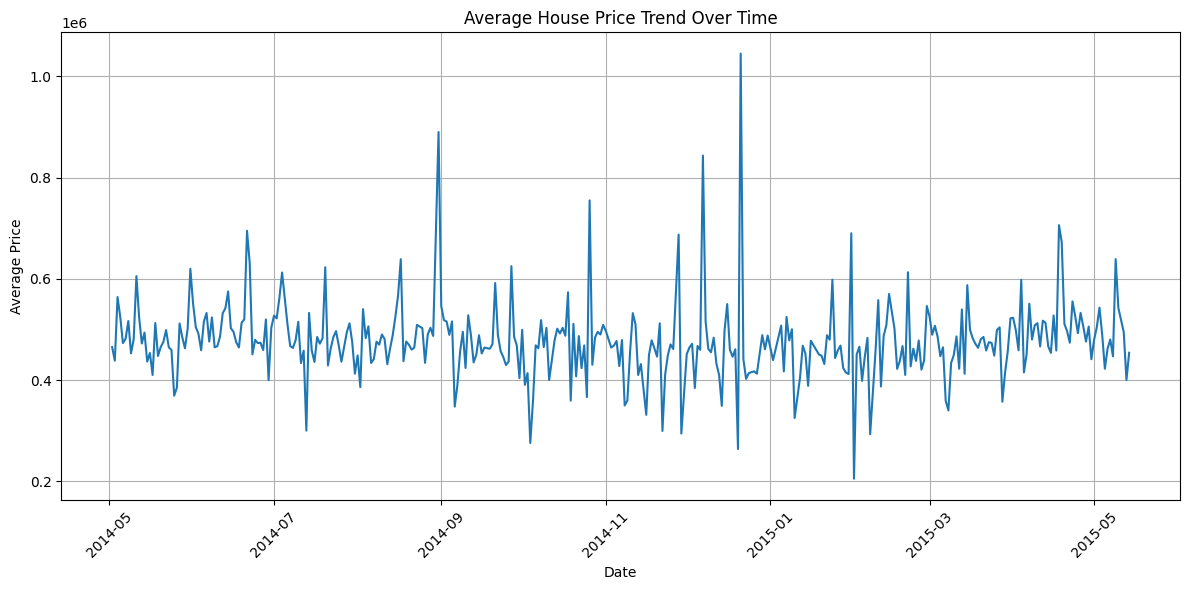

In [12]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(12, 6))
daily_avg_price = df.groupby('date')['price'].mean().reset_index()
plt.figure(figsize=(12, 6))
sns.lineplot(x='date', y='price', data=daily_avg_price)
plt.title('Average House Price Trend Over Time')
plt.xlabel('Date')
plt.ylabel('Average Price')
plt.grid(True)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [15]:
categorical_features = df.select_dtypes(include=['object', 'category']).columns
numerical_features = df.select_dtypes(include=['int64', 'float64']).columns

print(f"Categorical Features: {list(categorical_features)}")
print(f"Numerical Features: {list(numerical_features)}")
df_encoded = pd.get_dummies(df, columns=categorical_features, drop_first=True)

Categorical Features: []
Numerical Features: ['price', 'bedrooms', 'grade', 'has_basement', 'living_in_m2', 'renovated', 'nice_view', 'perfect_condition', 'real_bathrooms', 'has_lavatory', 'single_floor', 'month', 'quartile_zone', 'is_weekend']


In [17]:
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

X = df_encoded.drop('price', axis=1)
y = df_encoded['price']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print(f"X_train shape: {X_train.shape}")
print(f"X_test shape: {X_test.shape}")
print(f"y_train shape: {y_train.shape}")
print(f"y_test shape: {y_test.shape}")

X_train shape: (10882, 15)
X_test shape: (2721, 15)
y_train shape: (10882,)
y_test shape: (2721,)


In [19]:
from xgboost import XGBRegressor

X_train_processed = X_train.drop('date', axis=1, errors='ignore')
X_test_processed = X_test.drop('date', axis=1, errors='ignore')

xgb_model = XGBRegressor(random_state=42)
xgb_model.fit(X_train_processed, y_train)

print("XGBoost Regressor model trained successfully.")

XGBoost Regressor model trained successfully.


XGBoost Mean Absolute Error (MAE): 75523.72
XGBoost Mean Squared Error (MSE): 10768137329.17
XGBoost Root Mean Squared Error (RMSE): 103769.64
XGBoost R-squared (R2): 0.74


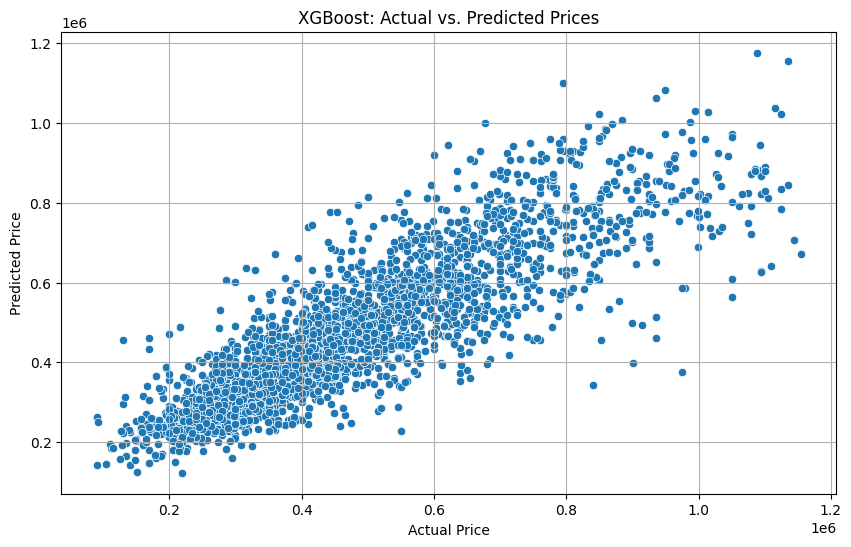

In [21]:
import numpy as np

y_pred_xgb = xgb_model.predict(X_test_processed)

mae_xgb = mean_absolute_error(y_test, y_pred_xgb)
mse_xgb = mean_squared_error(y_test, y_pred_xgb)
rmse_xgb = np.sqrt(mse_xgb)
r2_xgb = r2_score(y_test, y_pred_xgb)

print(f"XGBoost Mean Absolute Error (MAE): {mae_xgb:.2f}")
print(f"XGBoost Mean Squared Error (MSE): {mse_xgb:.2f}")
print(f"XGBoost Root Mean Squared Error (RMSE): {rmse_xgb:.2f}")
print(f"XGBoost R-squared (R2): {r2_xgb:.2f}")

plt.figure(figsize=(10, 6))
sns.scatterplot(x=y_test, y=y_pred_xgb)
plt.xlabel("Actual Price")
plt.ylabel("Predicted Price")
plt.title("XGBoost: Actual vs. Predicted Prices")
plt.grid(True)
plt.show()